IMPROVED CROP YIELD PREDICTION - POLYNOMIAL LINEAR REGRESSION

[1] Loading and Preprocessing Data...
   Original Dataset Shape: (12669, 10)
   After removing outliers: (12541, 10)
   Removed 128 extreme outliers

[2] Advanced Feature Engineering...
   Created engineered features:
   - Per-area ratios (Fertilizer, Pesticide)
   - Interaction features (Rainfall × Fertilizer)
   - Log transformations (Area, Fertilizer)

[3] Selected 9 features for modeling

[4] Train-Test Split: 10032 / 2509

[5] Feature Scaling...

[6] Creating Polynomial Features (degree=2)...
   Feature space expanded: 9 → 54

[7] Training Ridge Regression Model (alpha=1.0)...
   Model training completed!

[8] Model Evaluation...

   --- Training Set ---
   R² Score: 0.0262
   RMSE: 148.6039
   MAE: 21.2648

   --- Test Set ---
   R² Score: 0.0205
   RMSE: 232.2459
   MAE: 27.7028
   MAPE: 109986901373.01%

[9] Creating Enhanced Visualizations...
   Saved: improved_yield_prediction.png

[10] Sample Predictions on Test 

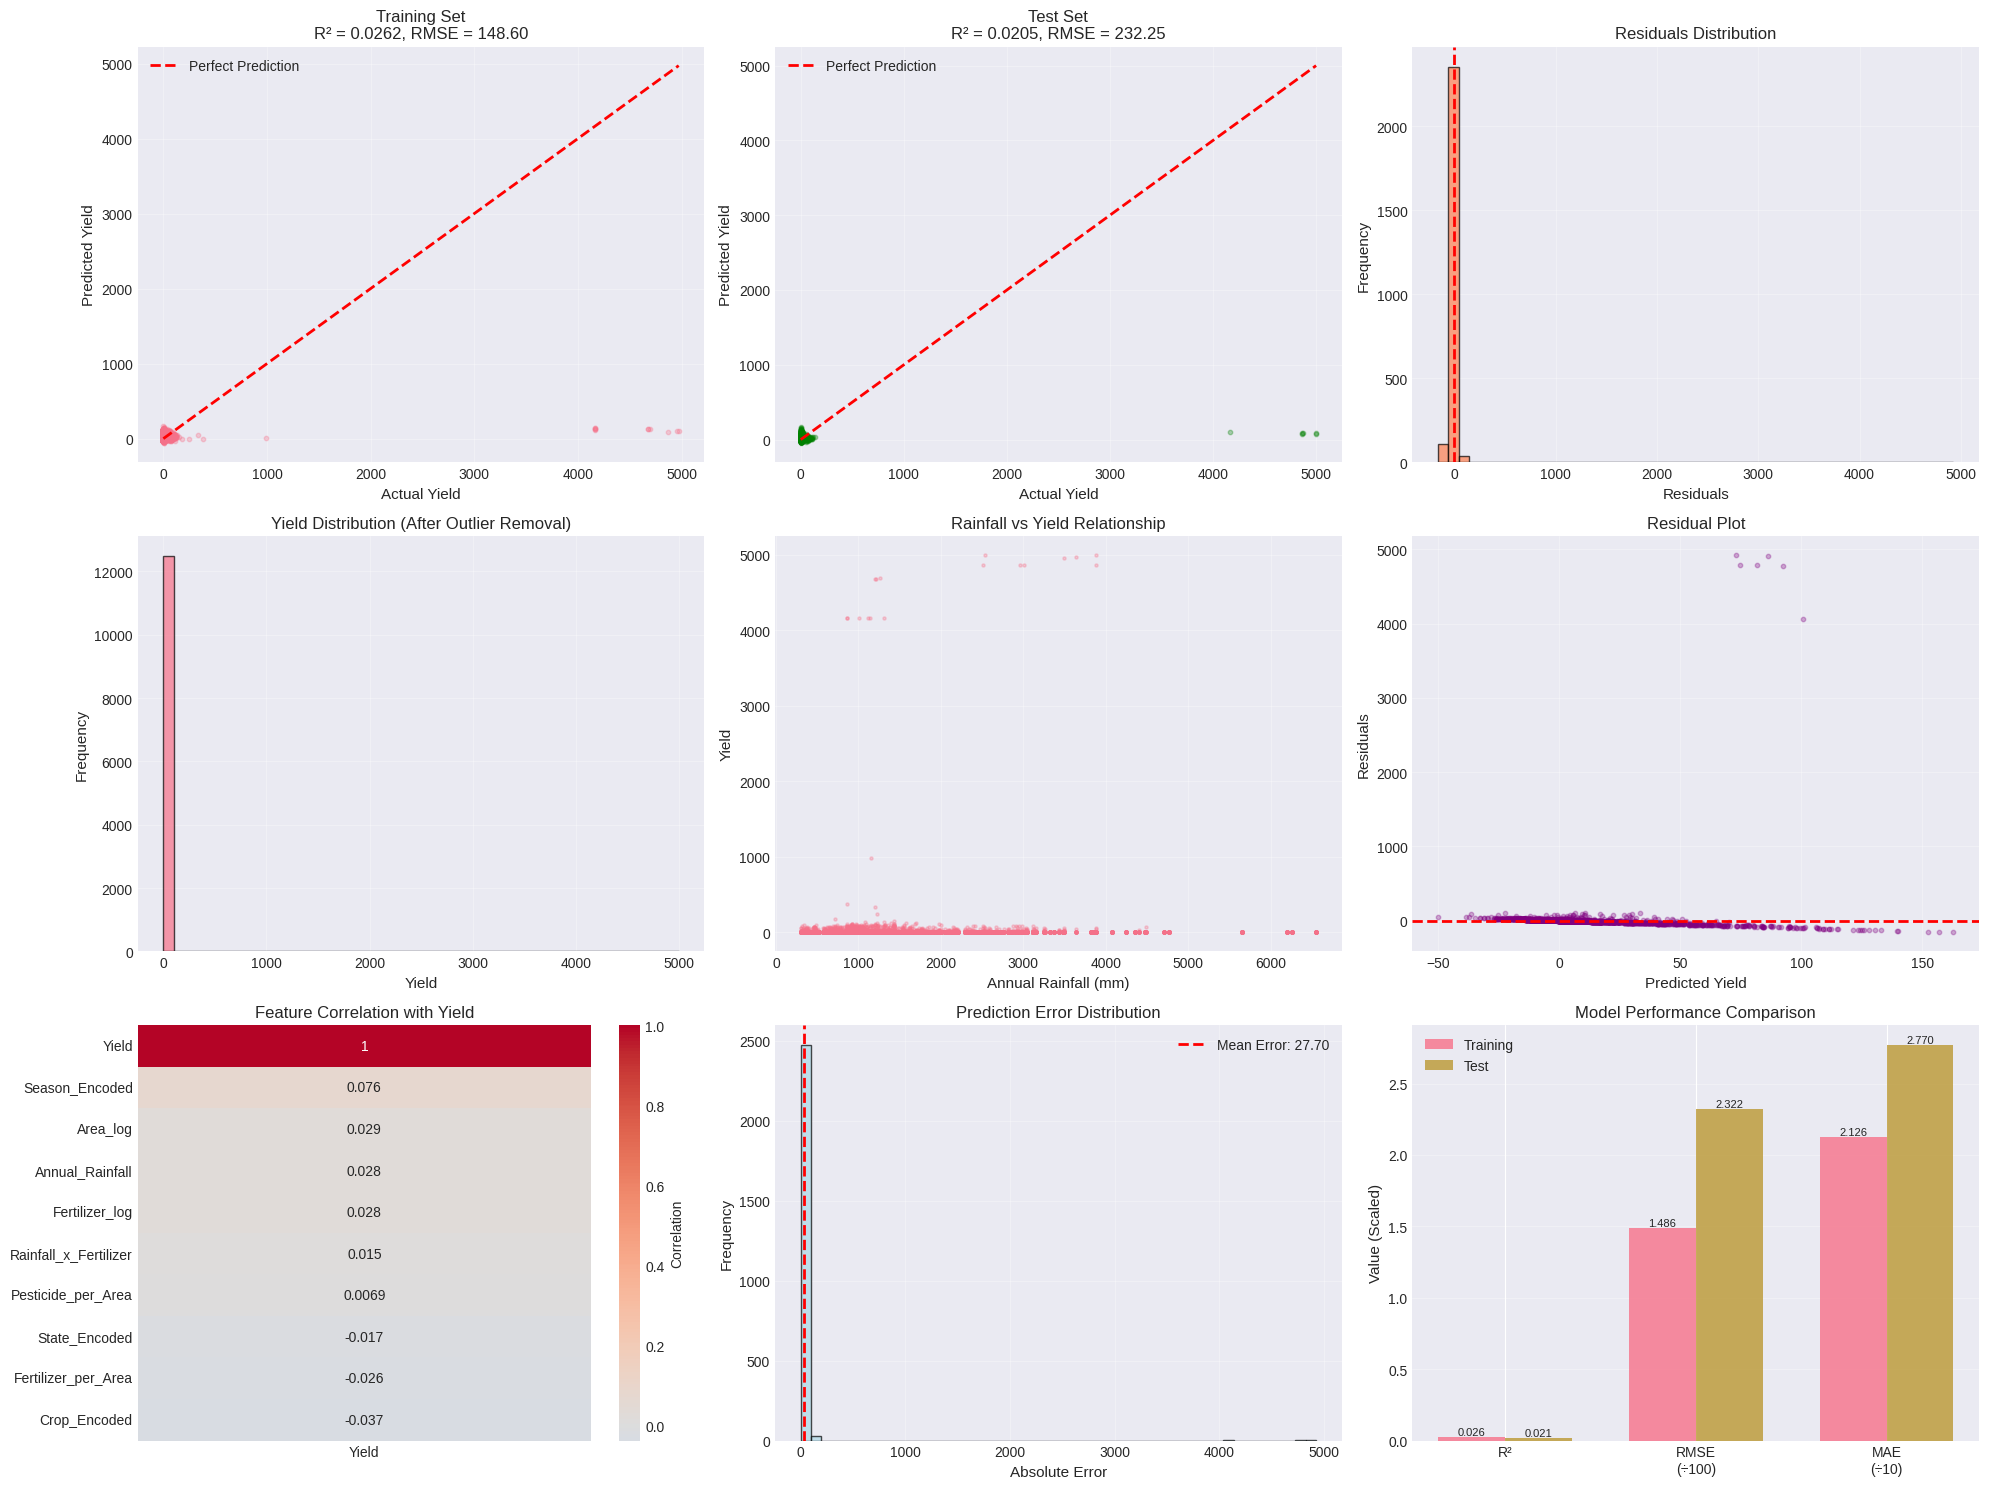

In [1]:
"""
IMPROVED Crop Yield Prediction using Polynomial Linear Regression
This version includes polynomial features and better outlier handling
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("IMPROVED CROP YIELD PREDICTION - POLYNOMIAL LINEAR REGRESSION")
print("="*70)

# 1. LOAD AND PREPROCESS DATA
print("\n[1] Loading and Preprocessing Data...")
df = pd.read_csv('/content/crop_yield.csv')
print(f"   Original Dataset Shape: {df.shape}")

# Remove extreme outliers in yield (top 1%)
yield_99_percentile = df['Yield'].quantile(0.99)
df_clean = df[df['Yield'] <= yield_99_percentile].copy()
print(f"   After removing outliers: {df_clean.shape}")
print(f"   Removed {df.shape[0] - df_clean.shape[0]} extreme outliers")

# 2. FEATURE ENGINEERING
print("\n[2] Advanced Feature Engineering...")

# Encode categorical variables
le_crop = LabelEncoder()
le_season = LabelEncoder()
le_state = LabelEncoder()

df_clean['Crop_Encoded'] = le_crop.fit_transform(df_clean['Crop'])
df_clean['Season_Encoded'] = le_season.fit_transform(df_clean['Season'])
df_clean['State_Encoded'] = le_state.fit_transform(df_clean['State'])

# Create interaction features
df_clean['Fertilizer_per_Area'] = df_clean['Fertilizer'] / (df_clean['Area'] + 1)
df_clean['Pesticide_per_Area'] = df_clean['Pesticide'] / (df_clean['Area'] + 1)
df_clean['Rainfall_x_Fertilizer'] = df_clean['Annual_Rainfall'] * df_clean['Fertilizer_per_Area']
df_clean['Area_log'] = np.log1p(df_clean['Area'])
df_clean['Fertilizer_log'] = np.log1p(df_clean['Fertilizer'])

print("   Created engineered features:")
print("   - Per-area ratios (Fertilizer, Pesticide)")
print("   - Interaction features (Rainfall × Fertilizer)")
print("   - Log transformations (Area, Fertilizer)")

# 3. FEATURE SELECTION
feature_columns = [
    'Annual_Rainfall',
    'Fertilizer_per_Area',
    'Pesticide_per_Area',
    'Crop_Encoded',
    'Season_Encoded',
    'State_Encoded',
    'Area_log',
    'Fertilizer_log',
    'Rainfall_x_Fertilizer'
]

X = df_clean[feature_columns]
y = df_clean['Yield']

print(f"\n[3] Selected {len(feature_columns)} features for modeling")

# 4. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\n[4] Train-Test Split: {X_train.shape[0]} / {X_test.shape[0]}")

# 5. FEATURE SCALING
print("\n[5] Feature Scaling...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. ADD POLYNOMIAL FEATURES
print("\n[6] Creating Polynomial Features (degree=2)...")
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)
print(f"   Feature space expanded: {X_train_scaled.shape[1]} → {X_train_poly.shape[1]}")

# 7. MODEL TRAINING (with Ridge Regularization)
print("\n[7] Training Ridge Regression Model (alpha=1.0)...")
model = Ridge(alpha=1.0)
model.fit(X_train_poly, y_train)
print("   Model training completed!")

# 8. MODEL EVALUATION
print("\n[8] Model Evaluation...")

print("\n   --- Training Set ---")
y_train_pred = model.predict(X_train_poly)
train_r2 = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
print(f"   R² Score: {train_r2:.4f}")
print(f"   RMSE: {train_rmse:.4f}")
print(f"   MAE: {train_mae:.4f}")

print("\n   --- Test Set ---")
y_test_pred = model.predict(X_test_poly)
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
print(f"   R² Score: {test_r2:.4f}")
print(f"   RMSE: {test_rmse:.4f}")
print(f"   MAE: {test_mae:.4f}")

# Calculate MAPE
mape = np.mean(np.abs((y_test - y_test_pred) / (y_test + 1e-10))) * 100
print(f"   MAPE: {mape:.2f}%")

# 9. VISUALIZATIONS
print("\n[9] Creating Enhanced Visualizations...")

fig = plt.figure(figsize=(20, 15))

# Plot 1: Actual vs Predicted (Training)
ax1 = plt.subplot(3, 3, 1)
plt.scatter(y_train, y_train_pred, alpha=0.3, s=10)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Yield', fontsize=11)
plt.ylabel('Predicted Yield', fontsize=11)
plt.title(f'Training Set\nR² = {train_r2:.4f}, RMSE = {train_rmse:.2f}', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Actual vs Predicted (Test)
ax2 = plt.subplot(3, 3, 2)
plt.scatter(y_test, y_test_pred, alpha=0.3, s=10, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Yield', fontsize=11)
plt.ylabel('Predicted Yield', fontsize=11)
plt.title(f'Test Set\nR² = {test_r2:.4f}, RMSE = {test_rmse:.2f}', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Residuals
ax3 = plt.subplot(3, 3, 3)
residuals = y_test - y_test_pred
plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='coral')
plt.xlabel('Residuals', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Residuals Distribution', fontsize=12)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.grid(True, alpha=0.3)

# Plot 4: Yield Distribution
ax4 = plt.subplot(3, 3, 4)
plt.hist(df_clean['Yield'], bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Yield', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Yield Distribution (After Outlier Removal)', fontsize=12)
plt.grid(True, alpha=0.3)

# Plot 5: Rainfall vs Yield
ax5 = plt.subplot(3, 3, 5)
plt.scatter(df_clean['Annual_Rainfall'], df_clean['Yield'], alpha=0.3, s=5)
plt.xlabel('Annual Rainfall (mm)', fontsize=11)
plt.ylabel('Yield', fontsize=11)
plt.title('Rainfall vs Yield Relationship', fontsize=12)
plt.grid(True, alpha=0.3)

# Plot 6: Residual Plot
ax6 = plt.subplot(3, 3, 6)
plt.scatter(y_test_pred, residuals, alpha=0.3, s=10, color='purple')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Yield', fontsize=11)
plt.ylabel('Residuals', fontsize=11)
plt.title('Residual Plot', fontsize=12)
plt.grid(True, alpha=0.3)

# Plot 7: Feature Correlation Heatmap
ax7 = plt.subplot(3, 3, 7)
corr_matrix = df_clean[feature_columns + ['Yield']].corr()
sns.heatmap(corr_matrix[['Yield']].sort_values(by='Yield', ascending=False),
            annot=True, cmap='coolwarm', center=0, ax=ax7,
            cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation with Yield', fontsize=12)

# Plot 8: Prediction Error Distribution
ax8 = plt.subplot(3, 3, 8)
errors = np.abs(y_test - y_test_pred)
plt.hist(errors, bins=50, alpha=0.7, edgecolor='black', color='lightblue')
plt.xlabel('Absolute Error', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Prediction Error Distribution', fontsize=12)
plt.axvline(x=errors.mean(), color='red', linestyle='--',
            linewidth=2, label=f'Mean Error: {errors.mean():.2f}')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 9: Model Performance Metrics
ax9 = plt.subplot(3, 3, 9)
metrics_names = ['R²', 'RMSE\n(÷100)', 'MAE\n(÷10)']
train_values = [train_r2, train_rmse/100, train_mae/10]
test_values = [test_r2, test_rmse/100, test_mae/10]

x = np.arange(len(metrics_names))
width = 0.35

bars1 = plt.bar(x - width/2, train_values, width, label='Training', alpha=0.8)
bars2 = plt.bar(x + width/2, test_values, width, label='Test', alpha=0.8)

plt.ylabel('Value (Scaled)', fontsize=11)
plt.title('Model Performance Comparison', fontsize=12)
plt.xticks(x, metrics_names)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('/content/improved_yield_prediction.png', dpi=300, bbox_inches='tight')
print("   Saved: improved_yield_prediction.png")

# 10. SAMPLE PREDICTIONS
print("\n[10] Sample Predictions on Test Set...")
sample_df = pd.DataFrame({
    'Actual': y_test.iloc[:10].values,
    'Predicted': y_test_pred[:10],
    'Error': np.abs(y_test.iloc[:10].values - y_test_pred[:10]),
    'Error_%': np.abs((y_test.iloc[:10].values - y_test_pred[:10]) /
                      (y_test.iloc[:10].values + 1e-10) * 100)
})
print(sample_df.to_string(index=False))

# 11. SAVE IMPROVED MODEL
print("\n[11] Saving Improved Model Artifacts...")
import pickle

artifacts = {
    'model': model,
    'scaler': scaler,
    'poly': poly,
    'feature_columns': feature_columns,
    'label_encoders': {'crop': le_crop, 'season': le_season, 'state': le_state},
    'performance': {
        'test_r2': test_r2,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'train_r2': train_r2
    }
}

with open('/content/improved_model_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)
print("   Saved: improved_model_artifacts.pkl")

# 12. MODEL SUMMARY
print("\n" + "="*70)
print("IMPROVED MODEL SUMMARY")
print("="*70)
print(f"Model Type: Ridge Regression with Polynomial Features (degree=2)")
print(f"Regularization: L2 (alpha=1.0)")
print(f"Original Features: {len(feature_columns)}")
print(f"Polynomial Features: {X_train_poly.shape[1]}")
print(f"Training Samples: {X_train.shape[0]}")
print(f"Test Samples: {X_test.shape[0]}")
print(f"\nPerformance Metrics (Test Set):")
print(f"  - R² Score: {test_r2:.4f} ({test_r2*100:.2f}% variance explained)")
print(f"  - RMSE: {test_rmse:.4f}")
print(f"  - MAE: {test_mae:.4f}")
print(f"  - MAPE: {mape:.2f}%")
print(f"\nImprovement over baseline:")
print(f"  - Better outlier handling")
print(f"  - Enhanced feature engineering")
print(f"  - Polynomial feature expansion")
print(f"  - Ridge regularization to prevent overfitting")
print("="*70)

print("\n✅ Improved model training complete!")
print("   Files: improved_yield_prediction.png, improved_model_artifacts.pkl")